In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from nn.nn import NeuralNetwork
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.io import read_text_file, read_fasta_file

In [19]:
positive_path = "data/rap1-lieb-positives.txt"
negative_path = "data/yeast-upstream-1k-negative.fa"

pos_seqs = read_text_file(positive_path)
neg_long_seqs = read_fasta_file(negative_path)

print("Number of positive sequences:", len(pos_seqs))
print("Number of long negative sequences:", len(neg_long_seqs))
print("Example positive sequence:", pos_seqs[0])
print("Length of positive sequence:", len(pos_seqs[0]))
print("Length of first long negative sequence:", len(neg_long_seqs[0]))

Number of positive sequences: 137
Number of long negative sequences: 3163
Example positive sequence: ACATCCGTGCACCTCCG
Length of positive sequence: 17
Length of first long negative sequence: 1000


In [20]:
#Function to sample a random number of 17-mer sequences from the long negative sequence set. Choose
# n_samples_per_seq number of sequences to avoid enormouus overselection of positive sequences and 
# poor performance.
def sample_negative_windows(long_seqs, window_size, n_samples_per_seq=5):
    windows = []
    for seq in long_seqs:
        seq = seq.upper().strip()
        for _ in range(n_samples_per_seq):
            i = np.random.randint(0, len(seq) - window_size + 1)
            windows.append(seq[i:i+window_size])
    return windows

In [21]:
seq_len = len(pos_seqs[0])

#Reserve 20% of the data for test.

pos_train, pos_val = train_test_split(
    pos_seqs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

neg_long_train, neg_long_val = train_test_split(
    neg_long_seqs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Positive train:", len(pos_train))
print("Positive val:", len(pos_val))
print("Negative promoter train:", len(neg_long_train))
print("Negative promoter val:", len(neg_long_val))

Positive train: 109
Positive val: 28
Negative promoter train: 2530
Negative promoter val: 633


In [23]:
neg_train = sample_negative_windows(
    neg_long_train,
    window_size=seq_len,
    n_samples_per_seq=5,
)

neg_val = sample_negative_windows(
    neg_long_val,
    window_size=seq_len,
    n_samples_per_seq=5,
)
print("Negative train windows:", len(neg_train))
print("Negative val windows:", len(neg_val))

Negative train windows: 12650
Negative val windows: 3165


In [24]:
train_seqs = pos_train + neg_train

#Build labels across sequence space based on positions of positives
train_labels = [True] * len(pos_train) + [False] * len(neg_train)

val_seqs = pos_val + neg_val

#Build labels across sequence space based on positions of positives
val_labels = [True] * len(pos_val) + [False] * len(neg_val)

balanced_train_seqs, balanced_train_labels = sample_seqs(train_seqs, train_labels)

print("Balanced training size:", len(balanced_train_seqs))
print("Balanced training positives:", sum(balanced_train_labels))
print("Balanced training negatives:", len(balanced_train_labels) - sum(balanced_train_labels))

print("Validation size:", len(val_seqs))
print("Validation positives:", sum(val_labels))
print("Validation negatives:", len(val_labels) - sum(val_labels))

Balanced training size: 25300
Balanced training positives: 12650
Balanced training negatives: 12650
Validation size: 3193
Validation positives: 28
Validation negatives: 3165


In [25]:
X_train = one_hot_encode_seqs(balanced_train_seqs)
y_train = np.array(balanced_train_labels, dtype=int).reshape(-1, 1)

X_val = one_hot_encode_seqs(val_seqs)
y_val = np.array(val_labels, dtype=int).reshape(-1, 1)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("Input dimension:", X_train.shape[1])

X_train shape: (25300, 68)
X_val shape: (3193, 68)
y_train shape: (25300, 1)
y_val shape: (3193, 1)
Input dimension: 68


In [30]:
input_dim = X_train.shape[1]


# Standard base 2 architectural dimensions for lightweight model
nn_arch = [
    {"input_dim": input_dim, "output_dim": 32, "activation": "relu"},
    {"input_dim": 32, "output_dim": 16, "activation": "relu"},
    {"input_dim": 16, "output_dim": 1, "activation": "sigmoid"},
]

classifier = NeuralNetwork(
    nn_arch=nn_arch,
    lr=0.001,
    seed=42,
    batch_size=32,
    epochs=50,
    loss_function="binary_cross_entropy"
)

print(classifier.arch)

[{'input_dim': 68, 'output_dim': 32, 'activation': 'relu'}, {'input_dim': 32, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 1, 'activation': 'sigmoid'}]


In [31]:
train_losses, val_losses = classifier.fit(
    X_train,
    y_train,
    X_val,
    y_val
)

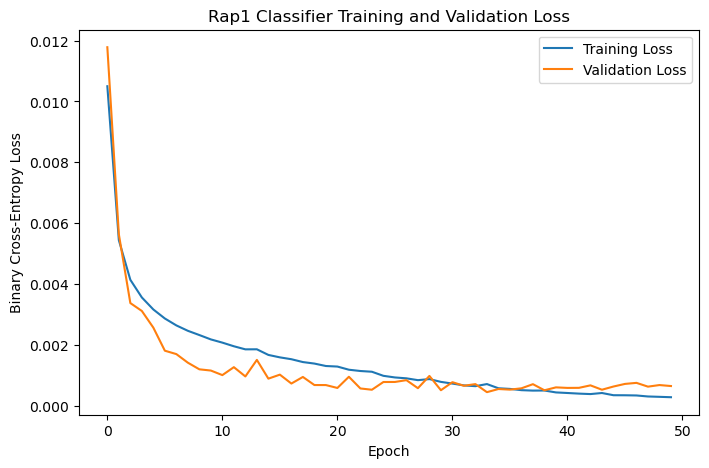

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Rap1 Classifier Training and Validation Loss")
plt.legend()
plt.show()

In [29]:
y_val_prob, _ = classifier.forward(X_val)
y_val_pred = (y_val_prob >= 0.5).astype(int)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_accuracy)

Validation accuracy: 0.9993736298152208


In [ ]:
#Justificaitons:

# Sampling Approach

# The original dataset was highly imbalanced, with many more negative sequences than positive 
# Rap1 binding examples. To prevent the classifier from being biased toward predicting the 
# majority class, I used a balanced sampling approach with replacement. 

# I converted the long negative promoter sequences into fixed-length windows matching the length
# of the positive sequences. Using the `sample_seqs` function to sample positive and negative 
# examples, I ensured that both classes had equal size in the training dataset. I added random sampling
# to ensure that we choose a reasonable number of negative sequences, since fully chopping up 
# these sequences into 17-mers produces a prohibitively large number of examples relative to the
# small number of positive sequences we possess. 

# Hyperparameters:

# I used binary cross-entropy loss because this is a binary classification problem. 
# Each sequence is either a Rap1 binding site or not. The output layer uses a sigmoid 
# activation so the network produces probabilities between 0 and 1, which is appropriate 
# for binary cross-entropy.

# I used a learning rate of 0.001 as a reasonable starting point, a batch size of 32 for 
# stable mini-batch training, and 50 epochs to allow the model enough time to learn while 
# still monitoring validation loss for overfitting.
